In [1]:
import pandas as pd
import os
from utils.ml_utils_v2 import EmissionsPredictionPipeline, MultiOutputEmissionsPipeline, XGBMultiOutputPipeline
from utils.eda_utils import EDAUtils, DataCleaningUtils
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
MAPPING_DIR_PATH = os.path.join(DATA_DIR_PATH, "mapping")
SSP_DIR_PATH = os.path.join(DATA_DIR_PATH, "ssp")
TRAINING_DIR_PATH = os.path.join(DATA_DIR_PATH, "training")

In [4]:
TRAINING_DATA_PATH = os.path.join(TRAINING_DIR_PATH, "training_data_v5.7.parquet") #NOTE: update filename as needed
training_df = pd.read_parquet(TRAINING_DATA_PATH)
training_df = training_df.drop(columns=["primary_id", "future_id"])
training_df.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.803011,0.496343,0.168613,0.203382,0.687640,0.651471,0.167822,0.318541,0.019632,0.206847,...,0.023251,0.519864,228.689851,6450.512091,11255.133506,1.110311e+09,0.0,1.099041,-45264.048312,-15326.861505
1,0.186768,0.161360,0.715659,0.520522,0.244624,0.432519,0.662078,0.659673,0.269362,0.823100,...,0.881897,0.307468,251.347424,6683.626925,11988.891140,1.032909e+09,0.0,0.463927,-40582.299332,-11855.185093
2,0.284609,0.129326,0.362011,0.434426,0.422840,0.683687,0.141129,0.492968,0.757714,0.625087,...,0.914823,0.078667,184.690777,5766.140732,9659.985315,1.135758e+09,0.0,0.697694,-34042.385712,-48447.698257
3,0.646471,0.046774,0.689050,0.070367,0.259922,0.168926,0.246849,0.185125,0.179946,0.490353,...,0.400283,0.013558,279.158564,7107.472492,12251.510957,1.138632e+09,0.0,0.695005,-48675.889667,5837.705269
4,0.833488,0.072018,0.845239,0.160506,0.398369,0.125452,0.115764,0.692139,0.655440,0.369429,...,0.453588,0.800351,336.834484,7737.210438,12165.795353,1.234887e+09,0.0,0.927158,-50583.469635,6625.620372


## EDA

In [5]:
edau = EDAUtils()

In [6]:
target_cols = [col for col in training_df.columns if not(col.startswith("group_"))]
target_cols

['emission_avg_last_five_years',
 'emission_total',
 'production_total',
 'production_cost_total',
 'technical_cost',
 'air_pollution',
 'num_jobs',
 'earning_per_job']

In [7]:
lhs_group_cols = [col for col in training_df.columns if col.startswith("group_")]
lhs_group_cols

['group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha',
 'group_2_frac_agrc_agriculture_production_lost',
 'group_3_frac_agrc',
 'group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture',
 'group_5_nemomod_entc_frac_min_share_production_fp_hydrogen',
 'group_6_nemomod_en',
 'group_7_',
 'group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel',
 'group_9_efficfactor_enfu_industrial_energy_fuel',
 'group_10_scalar_inen_energy_demand',
 'group_11_frac_inen_energy',
 'group_12_frac_ippu_cement_clinker',
 'group_13_ef_ippu_tonne_c',
 'group_14_ef_ippu_tonne_n2o_per_tonne_production',
 'group_15_ef_ippu_tonne_c',
 'group_16_pij_lndu',
 'group_17_frac_lndu_improved_pastures',
 'group_18_lndu_reallocation_factor',
 'group_19_gasrf_lsmm_biogas_anaerobic',
 'group_20_frac_lvst_mm',
 'group_21_frac_lvst_mm',
 'group_22_frac_lvst_mm_chickens',
 'group_23_ef_lvst_entferm',
 'group_24_frac_gnrl_eating_red_meat',
 'group_25_frac_ippu_production_with_co2_capture',
 'group_26_scalar_scoe_heat_energy_de

In [8]:
training_df[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,9.745300e+04,9.745300e+04,97453.000000,9.745300e+04,97453.000000,97453.000000,97453.000000,9.745300e+04
mean,2.867501e+04,5.604890e+05,10224.600982,1.138177e+09,220.650334,0.886245,-39480.502176,-1.383705e+04
std,4.534658e+05,4.920302e+06,1486.916604,6.252993e+07,2061.212895,0.229208,8461.238536,2.139279e+06
min,-1.795718e+06,-5.027928e+07,536.292921,9.516155e+08,-20980.180619,-0.042863,-62053.221570,-4.392501e+08
25%,1.328625e+02,5.081365e+03,9287.322361,1.093113e+09,72.371739,0.723566,-44696.325537,-2.266747e+04
50%,1.701974e+02,5.598300e+03,10294.109780,1.137053e+09,85.849721,0.896587,-39924.607229,-5.040506e+03
75%,2.091215e+02,6.135707e+03,11299.301617,1.182134e+09,100.999607,1.062689,-35041.125704,7.549866e+03
max,1.491463e+07,7.494342e+07,12860.280638,1.361191e+09,51787.858701,1.499377,27600.082244,3.909004e+08


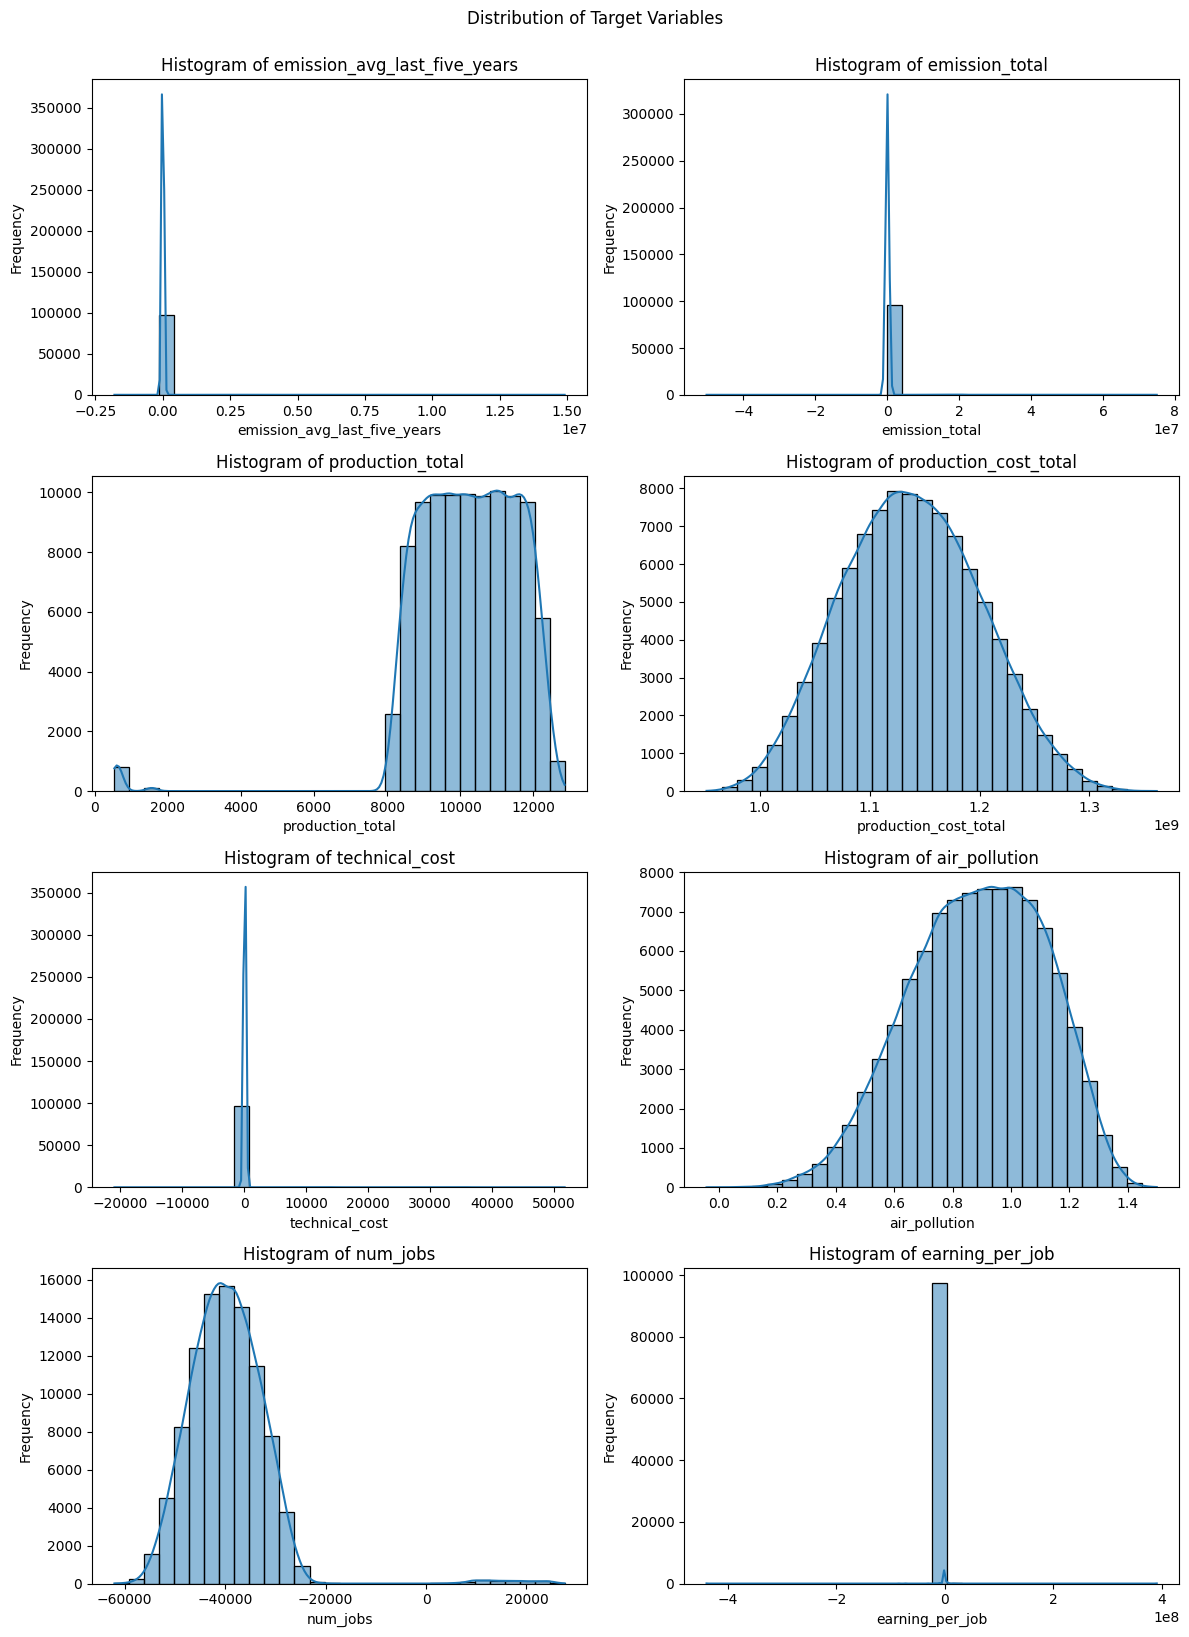

In [9]:
edau.plot_multiple_histograms(training_df, target_cols, title="Distribution of Target Variables")

In [13]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)
	


Correlation with target variable 'emission_total' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'emission_avg_last_five_years' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'production_total' (threshold: 0.1):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.8152
group_6_nemomod_en             : 0.1558


Correlation with target variable 'production_cost_total' (threshold: 0.1):
--------------------------------------------------
group_49_scalar_inen_energy_demand_other_product_manufacturing : 0.7350
group_10_scalar_inen_energy_demand : 0.4479
group_11_frac_inen_energy      : 0.3639
group_48_gdp_mmm_usd           : 0.3317


Correlation with target variable 'technical_cost' (threshold: 0.1):
--------------------------------------------------


Correlation with target variable 'air_pollution' (threshold: 0.1):
----------------------------

In [14]:
# Find constant / near-constant cols
# const_cols = edau.find_constant_columns(training_df)
# near_const_cols = edau.find_near_constant_columns(training_df, threshold=1e-2)
# print("Constant:", const_cols)
# print("Near-constant:", near_const_cols)

In [15]:
# Outlier inspection
outliers = edau.find_outlier_columns(training_df, method="iqr", factor=1.5)
print("Outlier percentages:", outliers)

Outlier percentages: {'emission_avg_last_five_years': 0.84, 'emission_total': 1.81, 'production_total': 0.92, 'production_cost_total': 0.1, 'technical_cost': 1.58, 'air_pollution': 0.13, 'num_jobs': 0.95, 'earning_per_job': 8.42}


## Data Cleaning

In [16]:
dcu = DataCleaningUtils()

In [17]:
training_df.shape

(97453, 67)

In [18]:
# # Check those -inf values in technical_cost
# technical_cost_neg_inf = training_df[training_df["technical_cost"] == -np.inf]
# technical_cost_neg_inf

In [19]:
# # filter out -inf values in technical_cost
# training_df = training_df[training_df["technical_cost"] != -np.inf]
# training_df.shape

In [20]:

training_df_cleaned = dcu.remove_outliers(training_df, method="iqr", factor=1.5)
print("Shape before removing outliers:", training_df.shape)
print("Shape after removing outliers:", training_df_cleaned.shape)

Shape before removing outliers: (97453, 67)
Shape after removing outliers: (87268, 67)


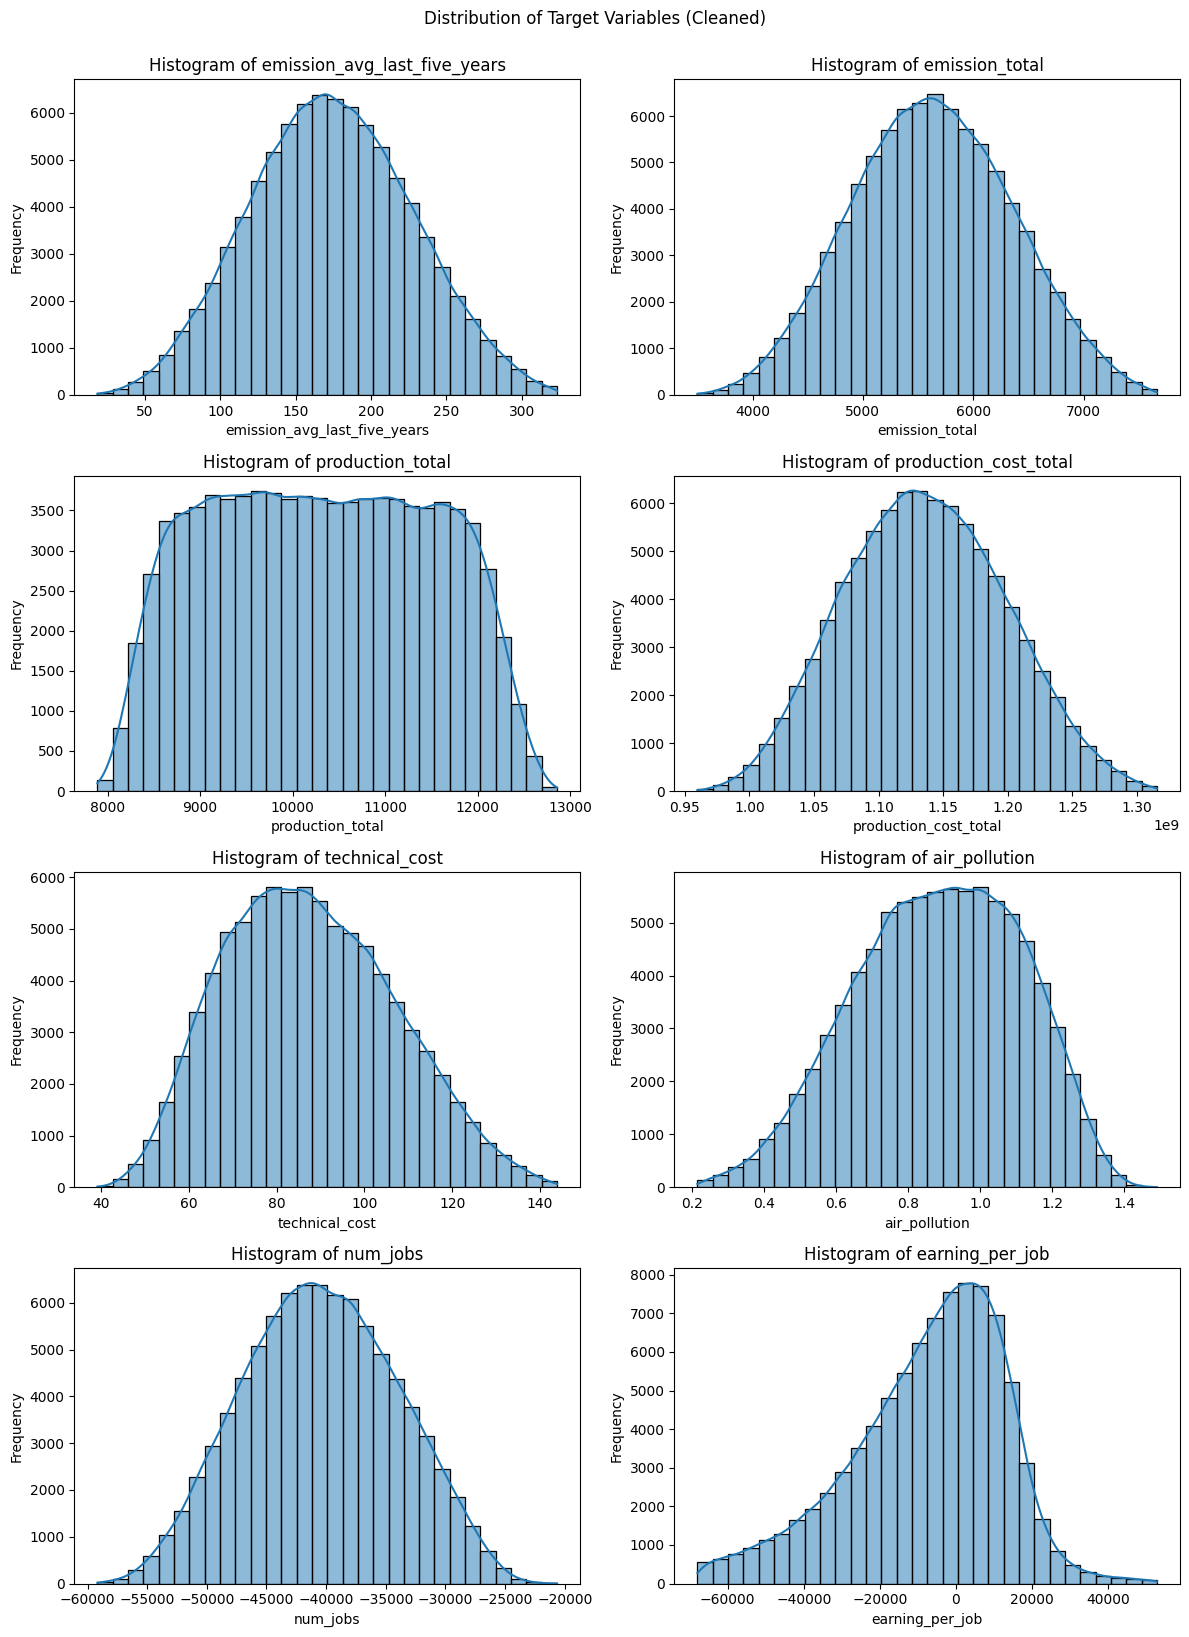

In [21]:
edau.plot_multiple_histograms(training_df_cleaned, target_cols, title="Distribution of Target Variables (Cleaned)")

In [22]:
outliers = edau.find_outlier_columns(training_df_cleaned, method="zscore", z_thresh=3.0)
print("Outlier percentages:", outliers)

Outlier percentages: {}


In [50]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols, method="spearman", threshold=0.2)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols, method="spearman", threshold=0.2)


Spearman correlation with target variable 'emission_total' (threshold: 0.2):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.6303
group_6_nemomod_en             : 0.4577
group_11_frac_inen_energy      : 0.4199


Spearman correlation with target variable 'emission_avg_last_five_years' (threshold: 0.2):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.6111
group_6_nemomod_en             : 0.4989
group_11_frac_inen_energy      : 0.4468


Spearman correlation with target variable 'production_total' (threshold: 0.2):
--------------------------------------------------
group_46_exports_enfu_pj_fuel  : 0.9761


Spearman correlation with target variable 'production_cost_total' (threshold: 0.2):
--------------------------------------------------
group_49_scalar_inen_energy_demand_other_product_manufacturing : 0.7409
group_10_scalar_inen_energy_demand : 0.4333
group_11_frac_inen_energy      : 0.3490
group_48_gdp_mmm_usd  

In [ ]:
edau.get_target_var_corr(training_df, "emission_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "emission_avg_last_five_years", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "production_cost_total", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "technical_cost", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "air_pollution", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "num_jobs", exclude_cols=target_cols)
edau.get_target_var_corr(training_df, "earning_per_job", exclude_cols=target_cols)

In [25]:
training_df_cleaned[target_cols].describe()

,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
count,87268.000000,87268.000000,87268.000000,8.726800e+04,87268.000000,87268.000000,87268.000000,87268.000000
mean,174.005045,5633.189370,10306.866995,1.136182e+09,87.643187,0.883434,-40433.087993,-7425.770081
std,53.350653,721.961544,1168.553774,6.178993e+07,19.184060,0.227514,6440.349027,20239.469225
min,18.567964,3500.316250,7890.443153,9.597111e+08,39.154090,0.215339,-59173.215010,-67969.951665
25%,136.202785,5121.216883,9318.177397,1.091532e+09,73.055696,0.721011,-45076.078778,-19500.836134
50%,173.101488,5624.937723,10297.073203,1.134927e+09,86.403604,0.893136,-40513.500647,-4321.683035
75%,211.045917,6140.401123,11292.064117,1.179736e+09,101.174859,1.058870,-35774.749048,7178.549841
max,323.503314,7665.166742,12856.786176,1.315539e+09,143.863459,1.490278,-20648.636758,52874.477535


In [26]:
# sns.pairplot(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

In [27]:
# edau.plot_correlation_matrix(training_df_cleaned[[c for c in training_df_cleaned.columns if c.startswith("group_38") or c.startswith("group_39")] + ["total_negative_emissions"]])

## ML

/opt/miniconda3/envs/ssp_la/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== XGB (TEST results) ===
emission_avg_last_five_years   → MAE: 2.6164 | RMSE: 3.3298 | R²: 0.9961 | SMAPE: 1.7%
emission_total                 → MAE: 30.8383 | RMSE: 38.9582 | R²: 0.9971 | SMAPE: 0.6%
production_total               → MAE: 11.6584 | RMSE: 14.5541 | R²: 0.9998 | SMAPE: 0.1%
production_cost_total          → MAE: 1152052.0337 | RMSE: 1455337.5726 | R²: 0.9994 | SMAPE: 0.1%
technical_cost                 → MAE: 0.4751 | RMSE: 0.6022 | R²: 0.9990 | SMAPE: 0.6%
air_pollution                  → MAE: 0.0158 | RMSE: 0.0210 | R²: 0.9915 | SMAPE: 2.2%
num_jobs                       → MAE: 388.4393 | RMSE: 523.9877 | R²: 0.9933 | SMAPE: 1.0%
earning_per_job                → MAE: 4908.3730 | RMSE: 9743.8325 | R²: 0.7680 | SMAPE: 41.9%

=== Cross-Validation (TEST only) ===
emission_avg_last_five_years   → MAE: 2.6370 ± 0.0282 | RMSE: 3.3523 ± 0.0362 | R²: 0.9960 ± 0.0001
emission_total                 → MAE: 31.0935 ± 0.5357 | RMSE: 39.3553 ± 0.6583 | R²: 0.9970 ± 0.0001
productio

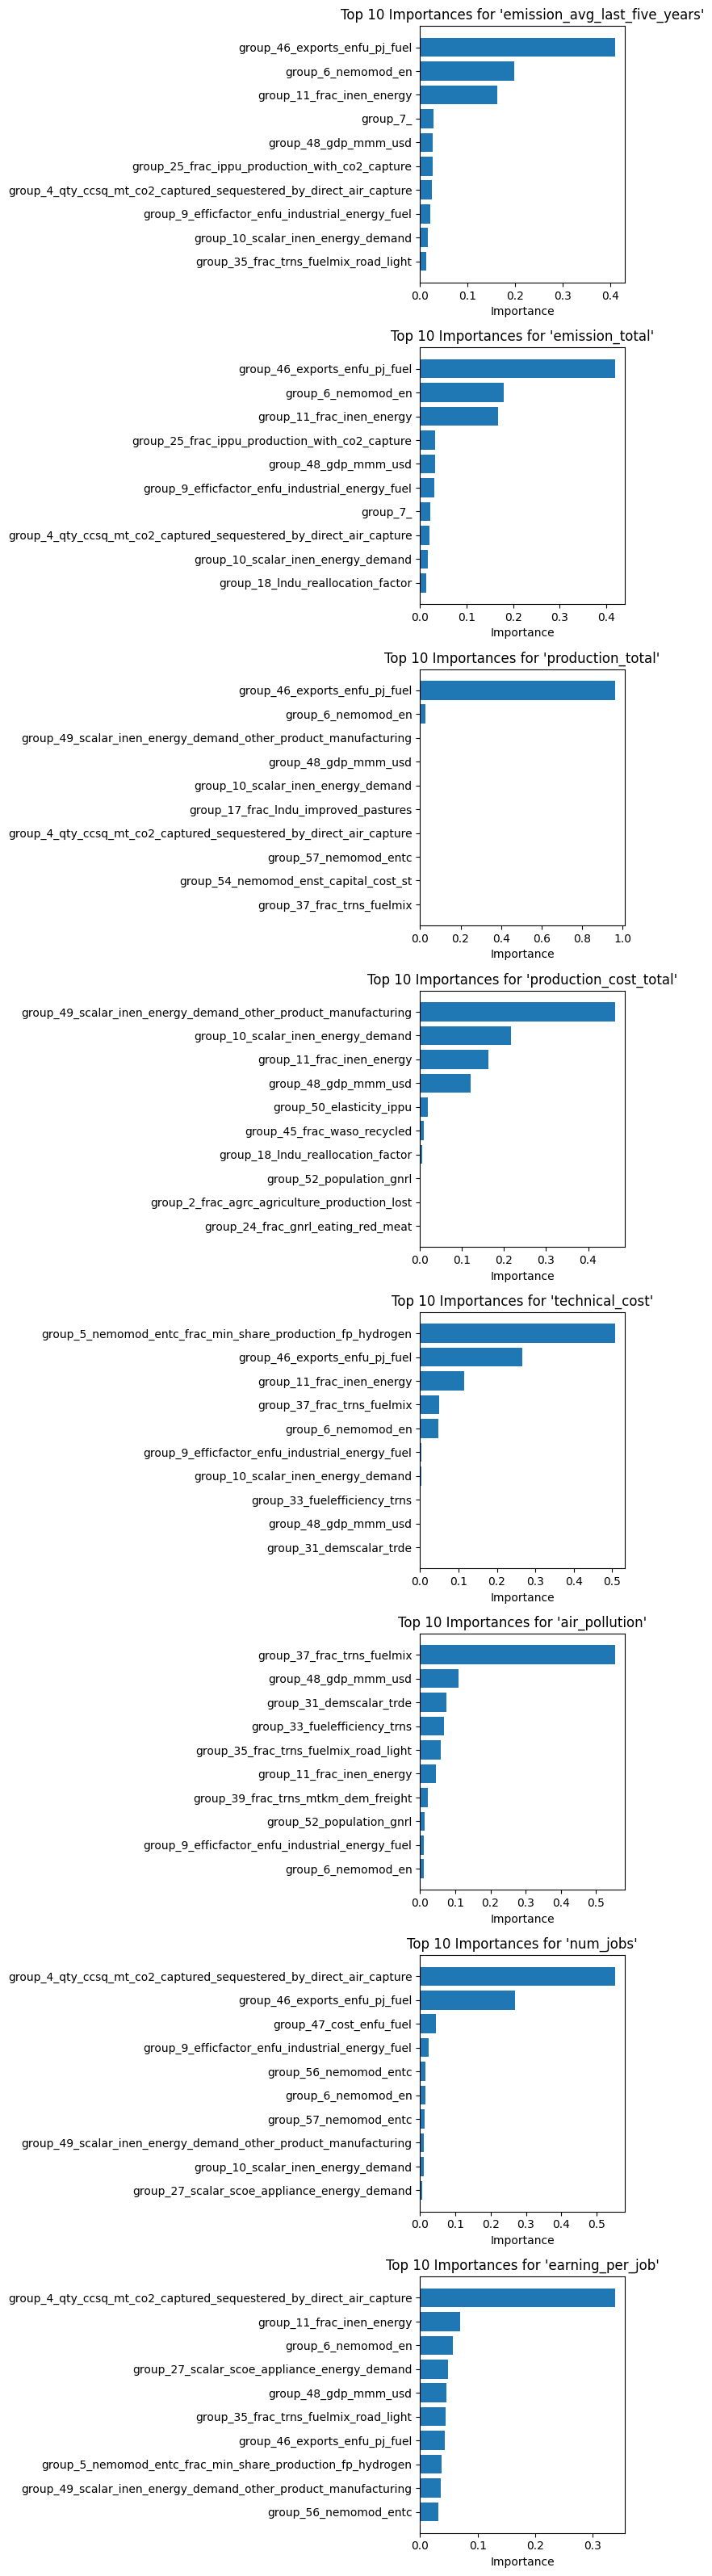

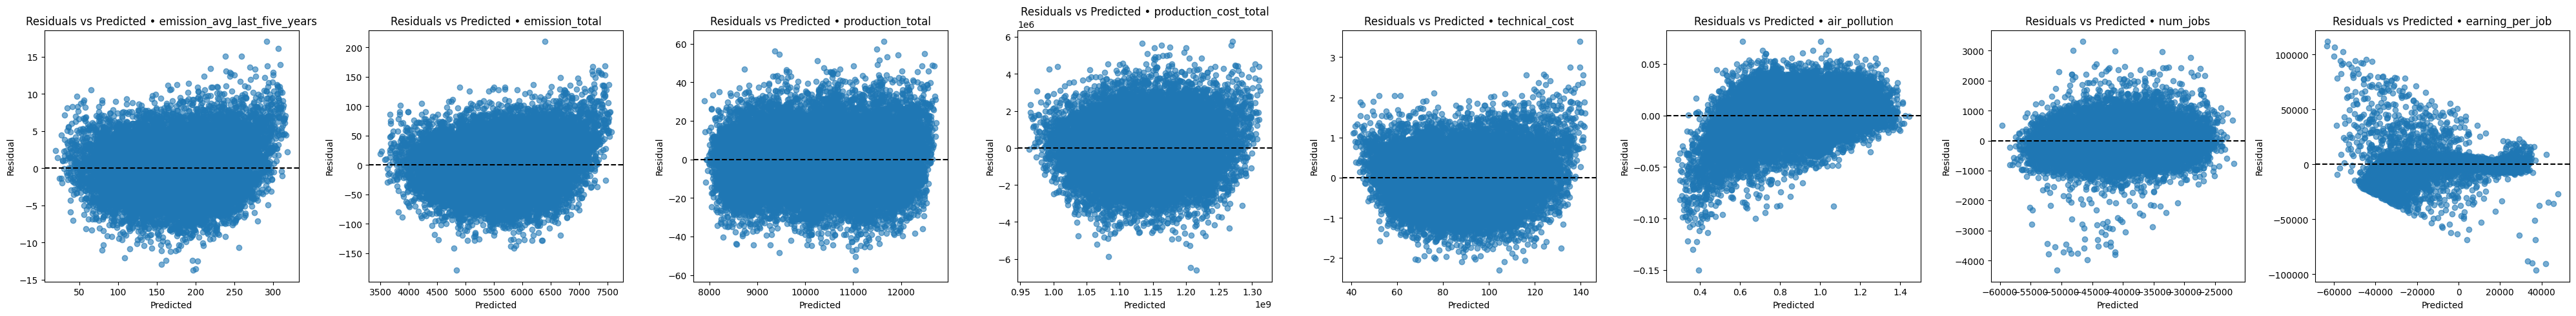

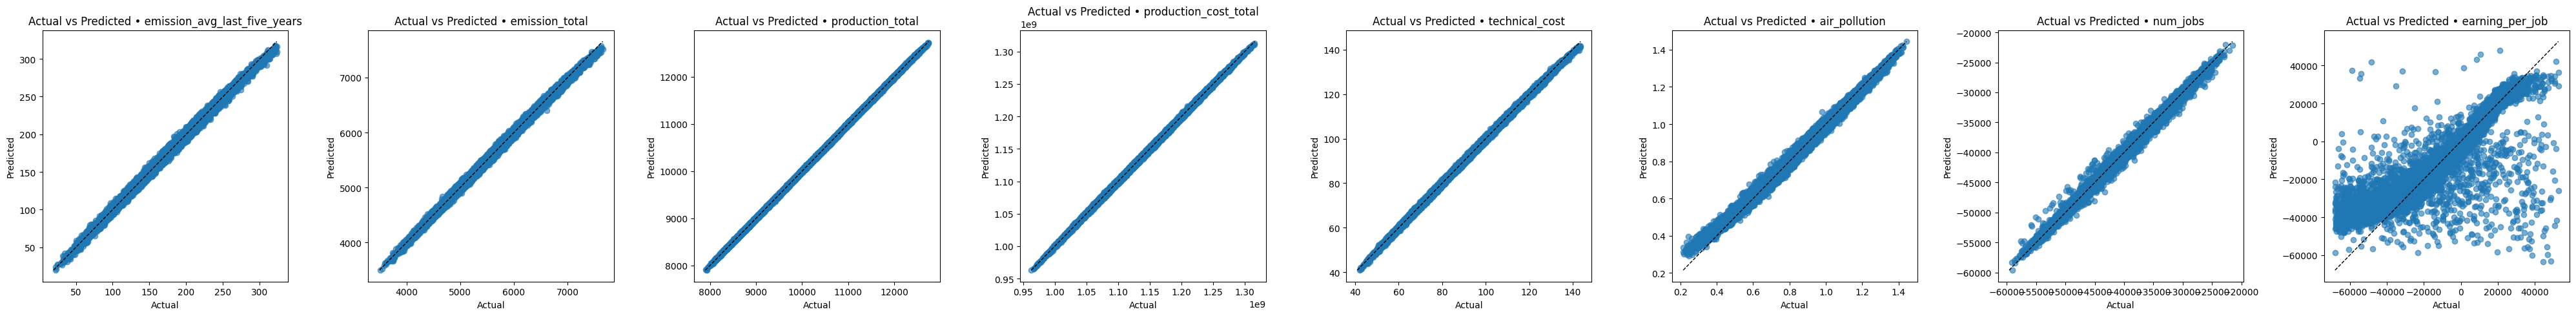

In [42]:
mulp = XGBMultiOutputPipeline(df=training_df_cleaned, targets=target_cols)
mulp.run(tune=True, log_transform=False, plot_figures=True)

In [43]:
# mulp = MultiOutputEmissionsPipeline(df=training_df_cleaned, targets=target_cols)
# mulp.run(tune=False, log_transform=False, plot_figures=True)

## Save the trained and tuned model and use it to predict new data

In [44]:
training_df_cleaned.head()

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
5,0.520800,0.388252,0.562131,0.142598,0.137790,0.136561,0.553560,0.581143,0.113373,0.477533,...,0.356569,0.455935,236.913089,6513.076178,11027.454424,1.250790e+09,128.649568,0.670695,-47065.477759,12980.682306
6,0.525366,0.416955,0.961288,0.743185,0.999075,0.794694,0.049932,0.826835,0.878786,0.766162,...,0.404877,0.916767,157.872682,5467.162630,9950.445752,1.043481e+09,55.737016,1.010040,-34661.864652,-51359.018045
7,0.964183,0.315060,0.315882,0.647131,0.294308,0.556260,0.643073,0.985451,0.704434,0.776848,...,0.666762,0.891455,159.417497,5540.713728,11332.342671,1.165257e+09,113.379852,1.001551,-35434.394843,-41652.372551
9,0.459433,0.215107,0.486077,0.960263,0.536174,0.231323,0.141548,0.593049,0.675545,0.997857,...,0.048976,0.925638,95.748862,4482.742874,8976.787331,1.163136e+09,79.813442,0.749540,-28447.407253,-47733.936128
10,0.087285,0.700954,0.184173,0.661443,0.854292,0.532374,0.474927,0.987841,0.606269,0.380392,...,0.125622,0.236726,135.840478,5130.224147,10599.231285,1.149989e+09,77.516800,1.176758,-38032.360917,-15192.905200


In [45]:
# Get a single row from training_df_cleaned for prediction
single_row = training_df_cleaned.iloc[0].drop(target_cols)
single_row = single_row.to_frame().T  # Convert to DataFrame
single_row

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_50_elasticity_ippu,group_51_elasticity_ippu_product_use,group_52_population_gnrl,group_53_elasticity_scoe_enerdem_per,group_54_nemomod_enst_capital_cost_st,group_55_nemomod_entc,group_56_nemomod_entc,group_57_nemomod_entc,group_58_elasticity_trde_mtkm_to_gdp_freight,group_59_elasticity_trde_pkm_to_gdppc
5,0.5208,0.388252,0.562131,0.142598,0.13779,0.136561,0.55356,0.581143,0.113373,0.477533,...,0.610014,0.303533,0.659881,0.116591,0.617813,0.138798,0.678098,0.505306,0.356569,0.455935


In [46]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
5                    235.942307     6524.725098      11032.663086   

   production_cost_total  technical_cost  air_pollution      num_jobs  \
5           1.251672e+09      127.653412       0.715052 -47216.546875   

   earning_per_job  
5     12625.042969  
Original values:
emission_avg_last_five_years    2.369131e+02
emission_total                  6.513076e+03
production_total                1.102745e+04
production_cost_total           1.250790e+09
technical_cost                  1.286496e+02
air_pollution                   6.706949e-01
num_jobs                       -4.706548e+04
earning_per_job                 1.298068e+04
Name: 5, dtype: float64


In [47]:
# Save the trained model
xgb_pipeline = mulp.pipeline  # only one now
TRAINED_MODELS_DIR = os.path.join(SCRIPT_DIR_PATH, "trained_models")
model_file_name = "xgb_pipeline_5.7.pkl"
os.makedirs(TRAINED_MODELS_DIR, exist_ok=True)
overwrite_existing_model = True  # Set to True to overwrite existing model

MODEL_PATH = os.path.join(TRAINED_MODELS_DIR, model_file_name)
if os.path.exists(MODEL_PATH) and not overwrite_existing_model:
    print(f"Model {model_file_name} already exists at {MODEL_PATH}. Skipping save.")
else:
    print(f"Saving model to {MODEL_PATH} ...")
    joblib.dump(xgb_pipeline, MODEL_PATH)
    print("✅ Model saved successfully.")

Saving model to /Users/tony/Documents/sisepuede_modeling/ssp_louisiana/metamodel/notebooks/trained_models/xgb_pipeline_5.7.pkl ...
✅ Model saved successfully.


In [48]:
# Load the trained model and test predictions
xgb_pipeline_loaded = joblib.load(MODEL_PATH)

In [49]:
# Predict using the trained model
predictions = mulp.predict(single_row)
print("Predictions for single row:")
print(predictions)
print("Original values:")
print(training_df_cleaned.iloc[0][target_cols])

Predictions for single row:
   emission_avg_last_five_years  emission_total  production_total  \
5                    235.942307     6524.725098      11032.663086   

   production_cost_total  technical_cost  air_pollution      num_jobs  \
5           1.251672e+09      127.653412       0.715052 -47216.546875   

   earning_per_job  
5     12625.042969  
Original values:
emission_avg_last_five_years    2.369131e+02
emission_total                  6.513076e+03
production_total                1.102745e+04
production_cost_total           1.250790e+09
technical_cost                  1.286496e+02
air_pollution                   6.706949e-01
num_jobs                       -4.706548e+04
earning_per_job                 1.298068e+04
Name: 5, dtype: float64


In [26]:
from pathlib import Path
TRAINED_MODELS_DIR = Path(TRAINED_MODELS_DIR)
mulp.X_test.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_x_test.parquet")
mulp.y_test.to_parquet(TRAINED_MODELS_DIR/"xgb_pipeline_5.5_y_test.parquet")


In [27]:
training_df_cleaned.to_parquet(TRAINED_MODELS_DIR / "xgb_pipeline_5.5_training_df.parquet")

In [28]:
training_df_cleaned

,group_1_ef_agrc_anaerobicdom_rice_kg_ch4_ha,group_2_frac_agrc_agriculture_production_lost,group_3_frac_agrc,group_4_qty_ccsq_mt_co2_captured_sequestered_by_direct_air_capture,group_5_nemomod_entc_frac_min_share_production_fp_hydrogen,group_6_nemomod_en,group_7_frac_fgtv_reduction_in_fugitive_leaks,group_8_frac_fgtv_drained_and_waste_ch4_flared_fuel,group_9_efficfactor_enfu_industrial_energy_fuel,group_10_scalar_inen_energy_demand,...,group_57_elasticity_ippu,group_58_elasticity_ippu_product_use,emission_avg_last_five_years,emission_total,production_total,production_cost_total,technical_cost,air_pollution,num_jobs,earning_per_job
0,0.073998,0.692822,0.979482,0.051058,0.188261,0.581816,0.698145,0.216501,0.371199,0.101867,...,0.792661,0.700647,134.250713,4713.726381,279.612528,4.567414e+08,-2.275659,1.033437,7184.221916,69844.538790
1,0.425023,0.729207,0.384489,0.436918,0.621826,0.168596,0.725935,0.167295,0.723122,0.186405,...,0.031865,0.682710,164.387644,5168.255434,276.395578,4.708078e+08,-7.468213,0.753391,10553.138793,114591.865227
2,0.881846,0.761554,0.325130,0.205597,0.237030,0.682775,0.718216,0.452701,0.761919,0.602002,...,0.578509,0.348348,104.151002,4411.805579,264.412432,4.615890e+08,-3.833560,1.181780,10329.819880,61421.909034
4,0.057338,0.477879,0.866591,0.161689,0.282495,0.282664,0.310182,0.991945,0.953932,0.864061,...,0.048358,0.042901,187.314145,5488.927406,243.699542,4.032488e+08,-6.069652,0.963409,8311.856268,132260.785244
5,0.511133,0.698963,0.711505,0.683995,0.437127,0.227332,0.355119,0.640986,0.844816,0.833615,...,0.256756,0.677597,154.259184,5011.043324,250.400601,4.181826e+08,-4.700765,0.677055,11844.335272,88061.428521
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,0.635142,0.603678,0.650826,0.938293,0.532791,0.458046,0.964056,0.549375,0.406465,0.937233,...,0.815408,0.150082,121.594420,4691.472707,248.818823,4.102299e+08,-4.849271,0.827842,20074.832845,91639.779457
959,0.523444,0.024740,0.631766,0.447112,0.909923,0.343413,0.604907,0.239868,0.477267,0.551167,...,0.710320,0.501973,162.146717,5202.036088,269.682673,4.655390e+08,-8.026771,0.250140,13488.129216,116293.548455
960,0.480615,0.560271,0.266827,0.643640,0.040585,0.020424,0.617931,0.743517,0.274302,0.251297,...,0.957187,0.471602,194.313061,5592.469537,292.994094,5.283043e+08,-5.954081,0.030116,16191.791192,78560.507381
961,0.083011,0.230503,0.294934,0.197481,0.891935,0.140418,0.135728,0.777188,0.748830,0.282061,...,0.979377,0.900547,200.981586,5717.910263,282.274217,4.902101e+08,-7.731554,0.563744,6795.072635,73039.006672
